In [2]:
import pandas as pd
import os.path as op
import numpy as np
from risk_experiment.utils import get_all_behavior
from tqdm.contrib.itertools import product
import matplotlib.pyplot as plt
import pingouin
import seaborn as sns


def get_pdf(subject, session, bids_folder='/data/ds-risk', mask='npcr', n_voxels=100, old=False):
    
    if n_voxels == 0:
        key = 'decoded_pdfs.volume.cv_voxel_selection.denoise.natural_space'

        if old:
            key += '.bak'

        pdf = op.join(bids_folder, 'derivatives', key, f'sub-{subject}', 'func', f'sub-{subject}_ses-{session}_mask-{mask}_space-T1w_pars.tsv')
    else:
        key = 'decoded_pdfs.volume.denoise.natural_space'

        if old:
            key += '.bak'

        pdf = op.join(bids_folder, 'derivatives', key, f'sub-{subject}', 'func', f'sub-{subject}_ses-{session}_mask-{mask}_nvoxels-{n_voxels}_space-T1w_pars.tsv')

    if op.exists(pdf):
        return pd.read_csv(pdf, sep='\t', index_col=[0])
    else:
        print(pdf)
        return None

def get_decoding_info(subject, session, bids_folder='/data/ds-risk', mask='npcr', n_voxels=100, old=False):

    pdf = get_pdf(subject, session, bids_folder=bids_folder, mask=mask, n_voxels=n_voxels, old=old) 

    if pdf is not None:
        pdf.columns = pdf.columns.astype(float)

        E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)
        E = pd.Series(np.trapz(pdf*pdf.columns.values[np.newaxis,:], pdf.columns, axis=1), index=pdf.index)

        E = pd.concat((E,), keys=[(subject, session, mask, n_voxels, old)],
        names=['subject', 'session', 'mask', 'n_voxels', 'old']).to_frame('E')

        E['sd'] = np.trapz(np.abs(E.values - pdf.columns.astype(float).values[np.newaxis, :]) * pdf, pdf.columns, axis=1)

        return E
    else:
        return pd.DataFrame(np.zeros((0, 0)))
    

from risk_experiment.utils.data import get_all_subject_ids
subjects = get_all_subject_ids()
sessions = ['3t2', '7t2']
masks = ['npcr']
n_voxels = [0]
old = [False]

pred = []
pdfs = []
keys = []

for (sub, session, mask, nv, o) in product(subjects, sessions, masks, n_voxels, old):
    pred.append(get_decoding_info(sub, session, '/data/ds-risk', mask, nv, old=o))
    pdfs.append(get_pdf(sub, session, '/data/ds-risk', mask, nv, old=o))
    keys.append((sub, session, mask, nv, o))

pdfs = pd.concat(pdfs, keys=keys, names=['subject', 'session', 'mask', 'n_voxels', 'old'])

  0%|          | 0/60 [00:00<?, ?it/s]

In [3]:
pred = pd.concat(pred)
df = get_all_behavior(drop_no_responses=False, bids_folder='/data/ds-risk')
pred = pred.join(df, how='inner')

100%|██████████| 30/30 [00:03<00:00,  8.90it/s]


In [9]:
# Sort by 'n1' for each subject and session seperately
pred_sorted = pred.groupby(['subject', 'session']).apply(lambda d: d.sort_values('n1'))


In [13]:
pred_sorted

E  \
subject session subject session trial_nr mask n_voxels old   run              
02      3t2     02      3t2     1        npcr 0        False 1    12.959348   
                                37       npcr 0        False 2    32.039243   
                                41       npcr 0        False 2    66.965593   
                                47       npcr 0        False 2    14.817128   
                                53       npcr 0        False 3     7.943009   
...                                                                     ...   
32      7t2     32      7t2     74       npcr 0        False 4    29.853575   
                                33       npcr 0        False 2    69.011014   
                                129      npcr 0        False 6    25.573215   
                                7        npcr 0        False 1    24.009966   
                                102      npcr 0        False 5    41.015969   

                                                                         sd  \
subject session subject session trial_nr mask n_voxels old   run              
02      3t2     02      3t2     1        npcr 0        False 1     8.327574   
                                37       npcr 0        False 2    17.288099   
                                41       npcr 0        False 2    24.373794   
                                47       npcr 0        False 2     6.000957   
                                53       npcr 0        False 3     5.783005   
...                                                                     ...   
32      7t2     32      7t2     74       npcr 0        False 4    16.745387   
                                33       npcr 0        False 2    31.758537   
                                129      npcr 0        False 6     8.474309   
                                7        npcr 0        False 1    11.244424   
                                102      npcr 0        False 5    13.230158   

                                                                        rt  \
subject session subject session trial_nr mask n_voxels old   run             
02      3t2     02      3t2     1        npcr 0        False 1    1.096017   
                                37       npcr 0        False 2    1.024171   
                                41       npcr 0        False 2    1.776277   
                                47       npcr 0        False 2    1.509301   
                                53       npcr 0        False 3    1.225128   
...                                                                    ...   
32      7t2     32      7t2     74       npcr 0        False 4    0.424018   
                                33       npcr 0        False 2    0.556739   
                                129      npcr 0        False 6    0.475698   
                                7        npcr 0        False 1    0.557759   
                                102      npcr 0        False 5    0.657551   

                                                                  uncertainty  \
subject session subject session trial_nr mask n_voxels old   run                
02      3t2     02      3t2     1        npcr 0        False 1            1.0   
                                37       npcr 0        False 2            1.0   
                                41       npcr 0        False 2            2.0   
                                47       npcr 0        False 2            2.0   
                                53       npcr 0        False 3            1.0   
...                                                                       ...   
32      7t2     32      7t2     74       npcr 0        False 4            1.0   
                                33       npcr 0        False 2            1.0   
                                129      npcr 0        False 6            1.0   
                                7        npcr 0        False 1            1.0   
                               

In [25]:
pred['error'] = pred['n1'] - pred['E']
pred['abs(error)'] = np.abs(pred['error'])

In [124]:
pred['n1_bin'] = pred.groupby(['subject', 'session'])['n1'].transform(lambda d: pd.cut(d, np.arange(5, 105, 5)))

pred['n1_bin'] = pred['n1_bin'].apply(lambda x: x.mid)

In [125]:
pred['expected_error'] = pred.groupby(['subject', 'session'])['n1'].transform(lambda d: (d-d.mean()).abs())

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_64863/2041861027.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sns.FacetGrid(pred.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean().reset_index(), height=5.)


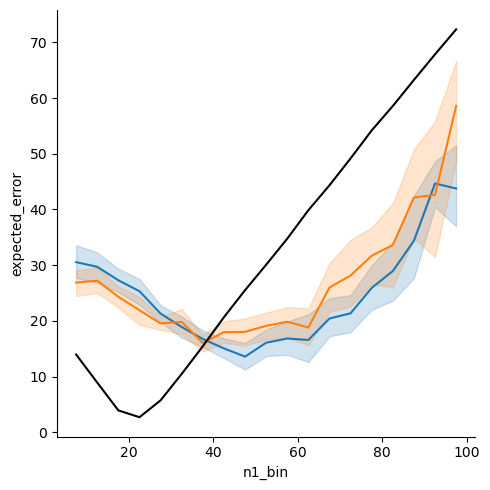

In [126]:
g = sns.FacetGrid(pred.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean().reset_index(), height=5.)

g.map_dataframe(sns.lineplot, 'n1_bin', 'abs(error)', hue='session')
g.map_dataframe(sns.lineplot, x='n1_bin', y='expected_error', color='black', errorbar=None)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_64863/3542302825.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = pred.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean()


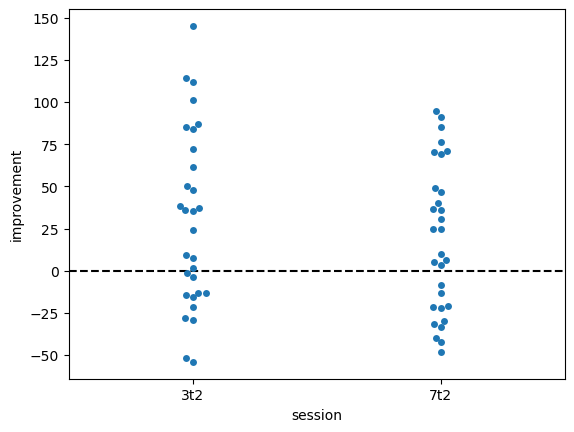

In [136]:
tmp = pred.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean()

improvement = (tmp['expected_error'] - tmp['abs(error)'])

sns.swarmplot(x='session', y='improvement', data=improvement.groupby(['subject' ,'session']).sum().to_frame('improvement').reset_index())
plt.axhline(0.0, c='k', ls='--')

In [221]:
prior_n1 = df.groupby(['subject', 'session', 'n1']).size().unstack('n1').fillna(0)

prior_n1 /= prior_n1.sum(1).values[:, np.newaxis]

# prior_n1.sum(1jjjj)
# prior_n1 /= prior_n1.sum()

posterior_pdfs = pdfs * prior_n1
posterior_pdfs /= posterior_pdfs.sum(1).values[:, np.newaxis]



In [302]:
prior_n1_smoothed = prior_n1.rolling(20, axis=1, center=True).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_64863/1303853996.py:1: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  prior_n1_smoothed = prior_n1.rolling(20, axis=1, center=True).mean()


/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (30) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (30) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)


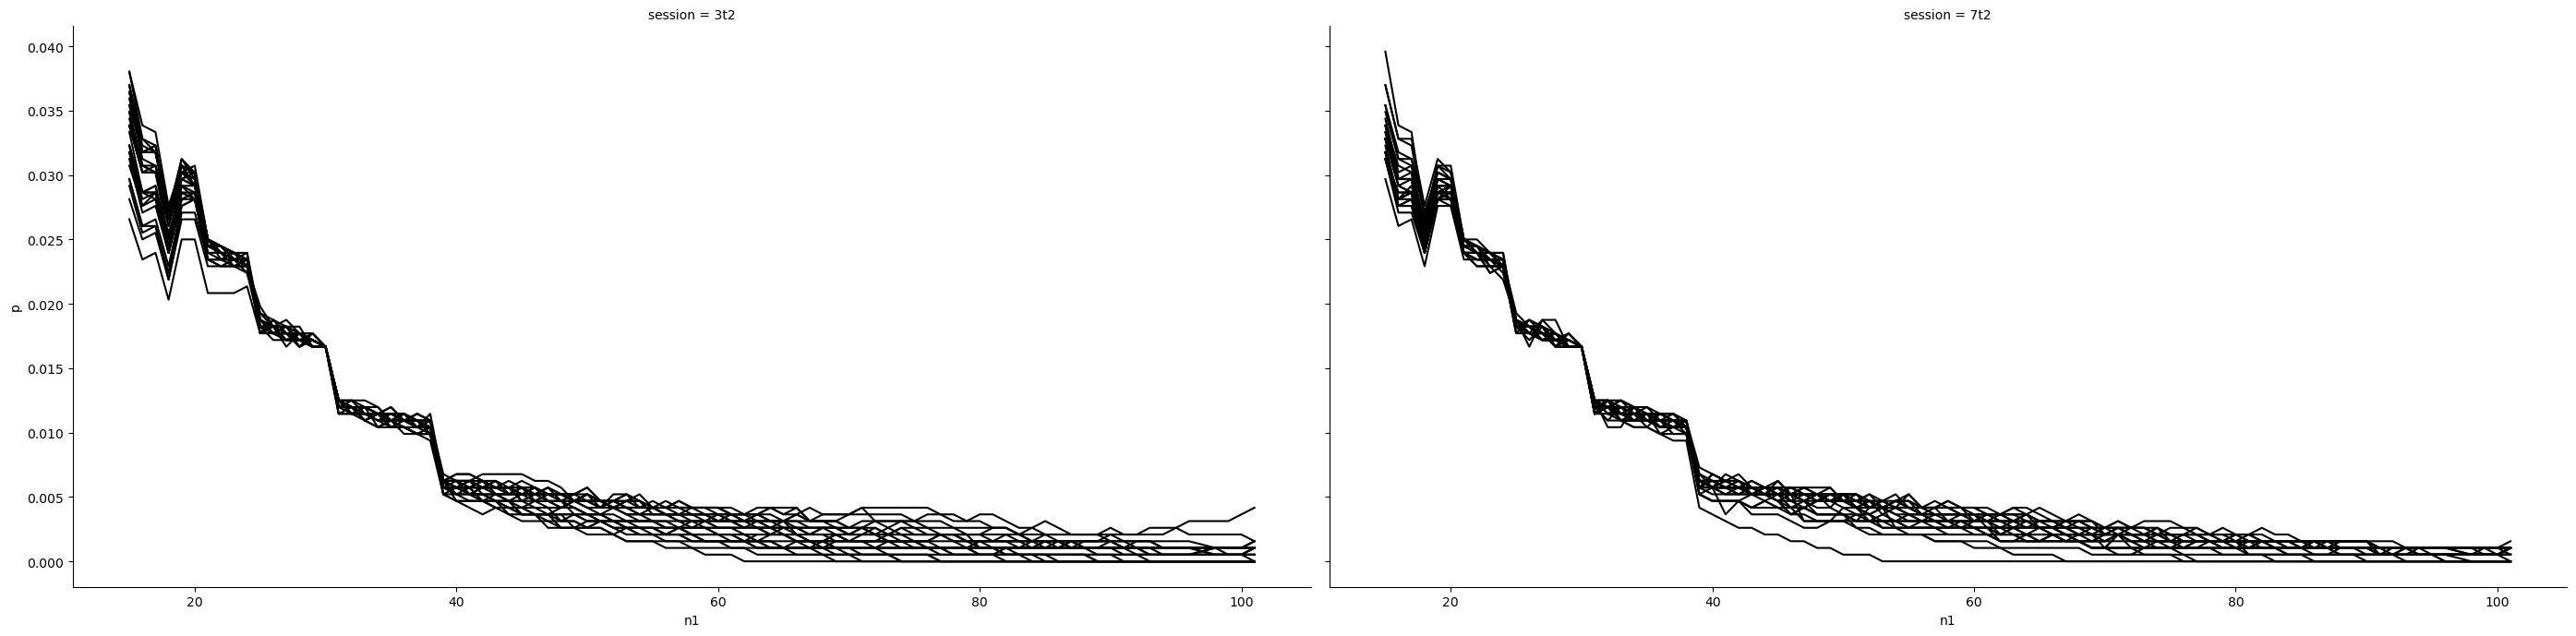

In [303]:

g = sns.FacetGrid(prior_n1_smoothed.stack().to_frame('p').reset_index(), col='session', height=7, aspect=2)
g.map_dataframe(sns.lineplot, 'n1', 'p', hue='subject', palette=['k'])

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (30) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)


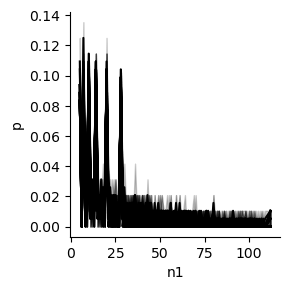

In [284]:
g = sns.FacetGrid(prior_n1.stack().to_frame('p').reset_index(), col='session')

g.map_dataframe(sns.lineplot, 'n1', 'p', hue='subject', palette=['k'])

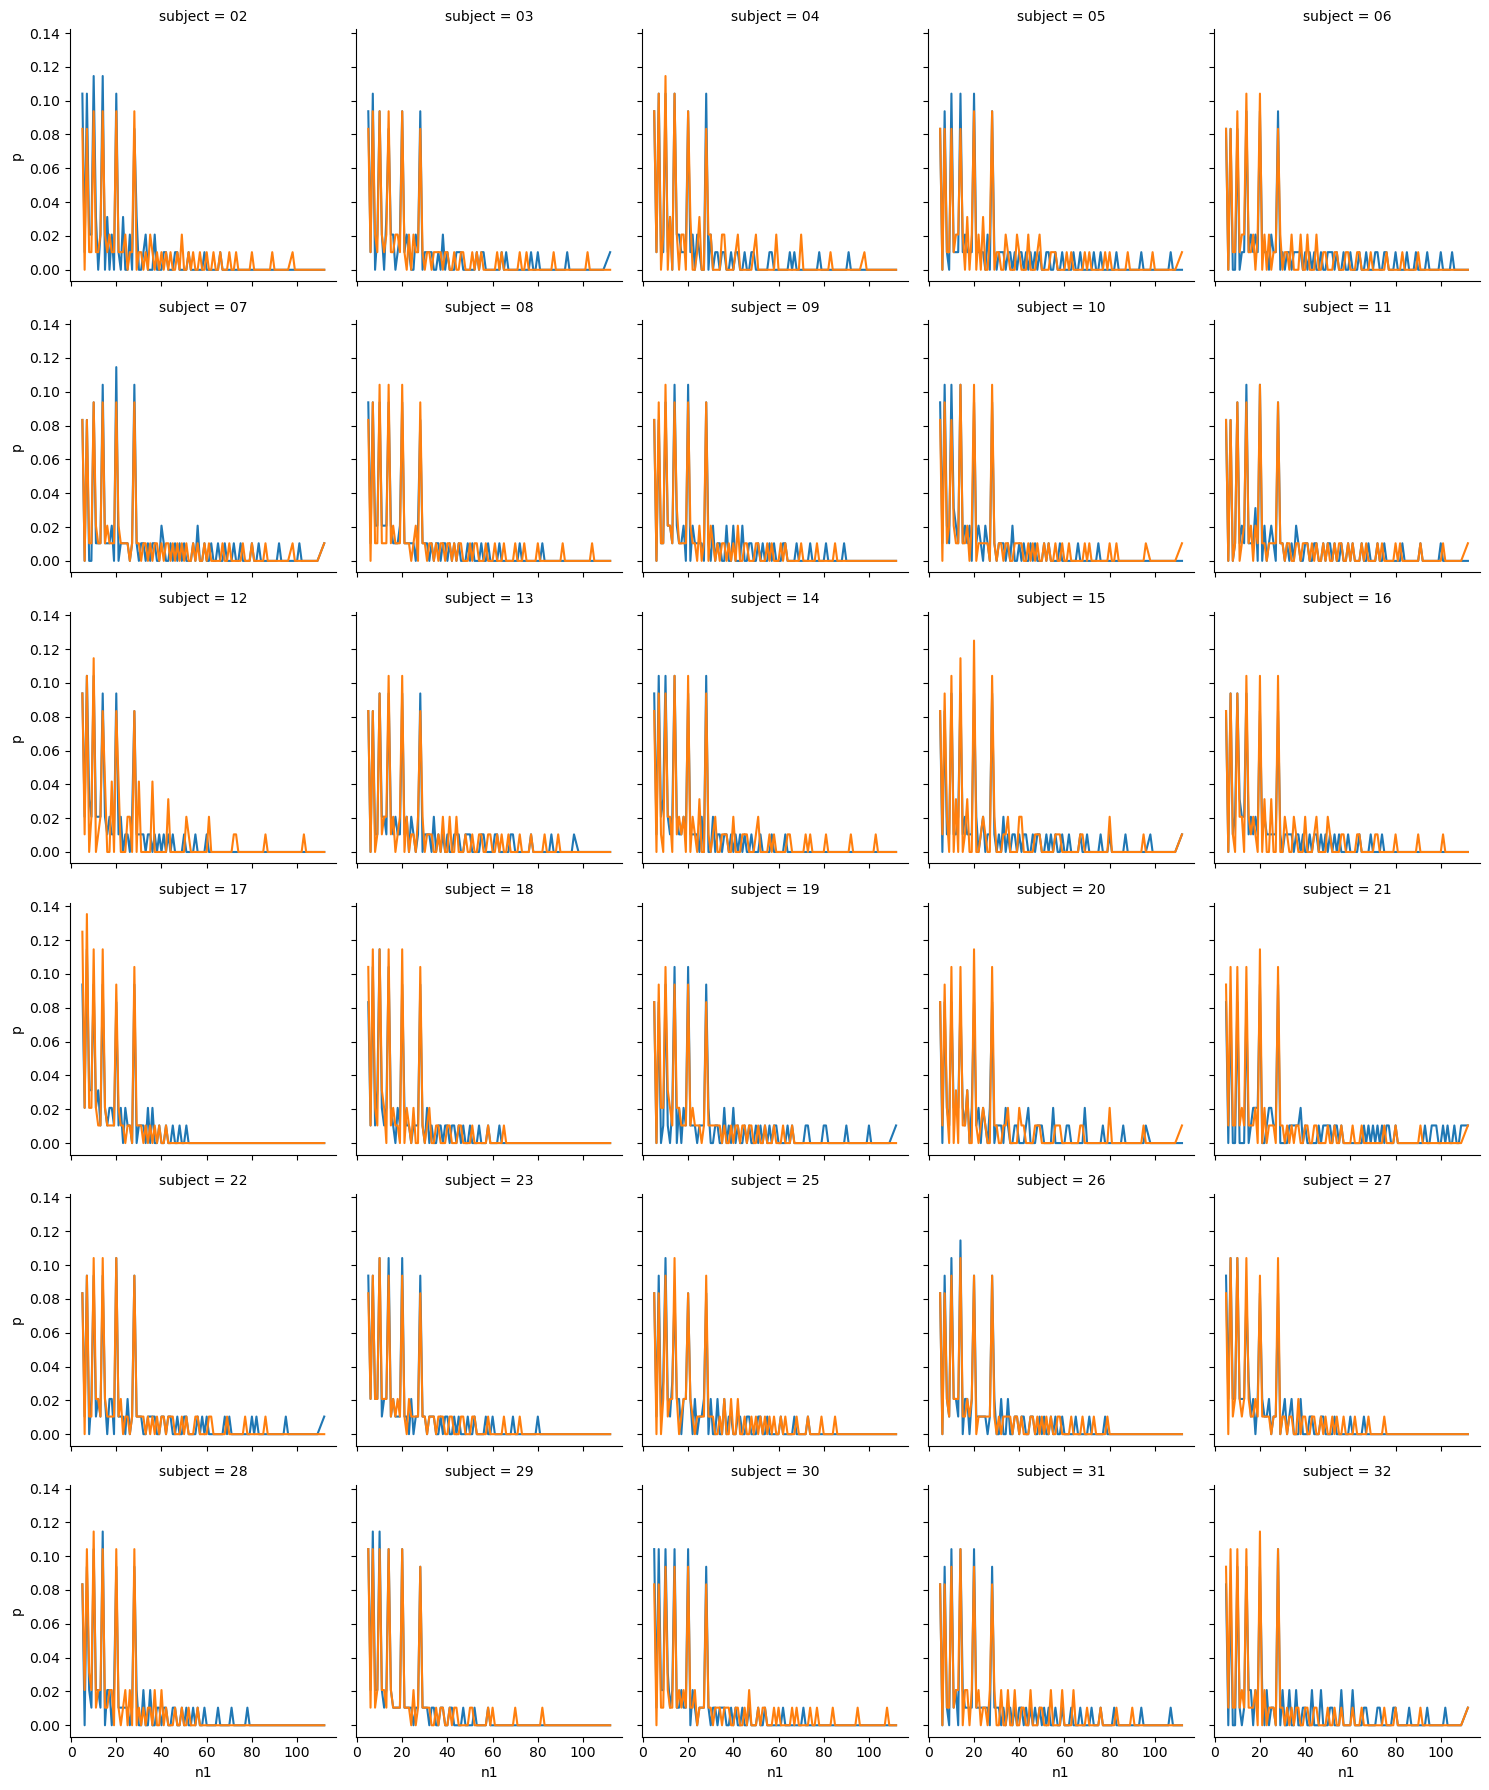

In [231]:
sns.FacetGrid(prior_n1.stack().to_frame('p').reset_index(), hue='session', col='subject',  col_wrap=5).map_dataframe(sns.lineplot, 'n1', 'p')

In [255]:
E_posterior = (posterior_pdfs*posterior_pdfs.columns.values[np.newaxis, :] / posterior_pdfs.sum(1).values[:, np.newaxis]).sum(1).to_frame("E")
E_posterior['sd'] = np.trapz(np.abs(E_posterior.values - pdfs.columns.astype(float).values[np.newaxis, :]) * pdfs, pdfs.columns, axis=1)

pred_post = E_posterior.join(df)

pred_post['error'] = pred_post['n1'] - pred_post['E']
pred_post['abs(error)'] = np.abs(pred_post['error'])



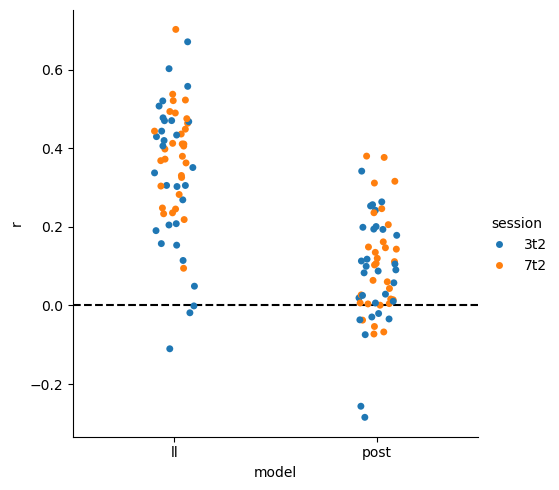

In [262]:
r_post = pred_post.groupby(['subject', 'session', 'run'])[['n1', 'E']].corr().iloc[0::2, 1].to_frame('r')
r_ll = pred.groupby(['subject', 'session', 'run'])[['n1', 'E']].corr().iloc[0::2, 1].to_frame('r')


r_error_post = pred_post.groupby(['subject', 'session', 'run'])[['abs(error)', 'sd']].apply(lambda d: pingouin.corr(d['abs(error)'], d['sd'])).reset_index()
r_error_ll = pred.groupby(['subject', 'session', 'run'])[['abs(error)', 'sd']].apply(lambda d: pingouin.corr(d['abs(error)'], d['sd'])).reset_index()


r_error = pd.concat((r_error_post, r_error_ll), keys=['post', 'll'], names=['model'])

sns.catplot(x='model', y='r', data=r_error.reset_index().groupby(['subject', 'model', 'session'])[['r']].mean().reset_index(), hue='session')


plt.axhline(0.0, c='k', ls='--')


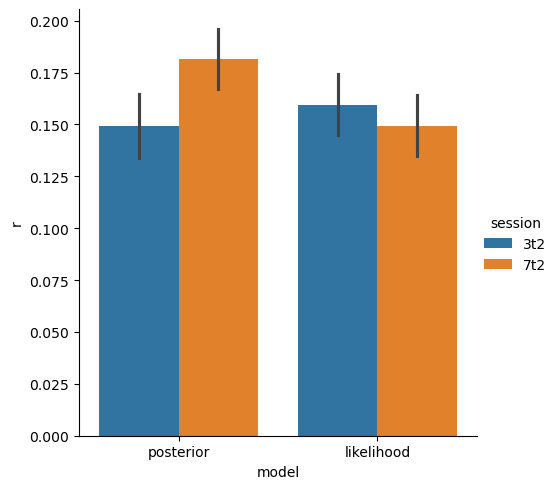

In [264]:
r = pd.concat((r_post, r_ll), keys=['posterior', 'likelihood'], names=['model']).reset_index()

sns.catplot(x='model', y='r', data=r.reset_index(), kind='bar', hue='session', errorbar='se')

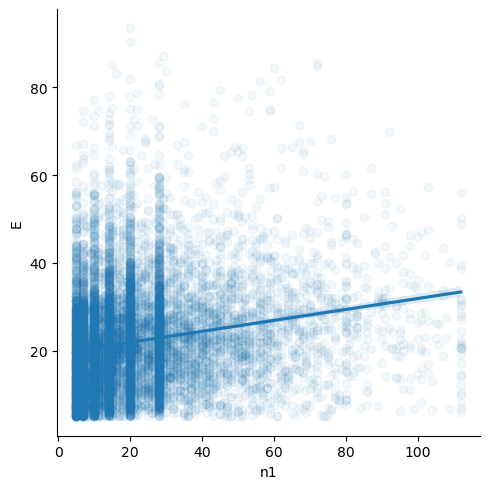

In [276]:
sns.lmplot(data=pred_post, x='n1', y='E', scatter_kws={'alpha':.05})

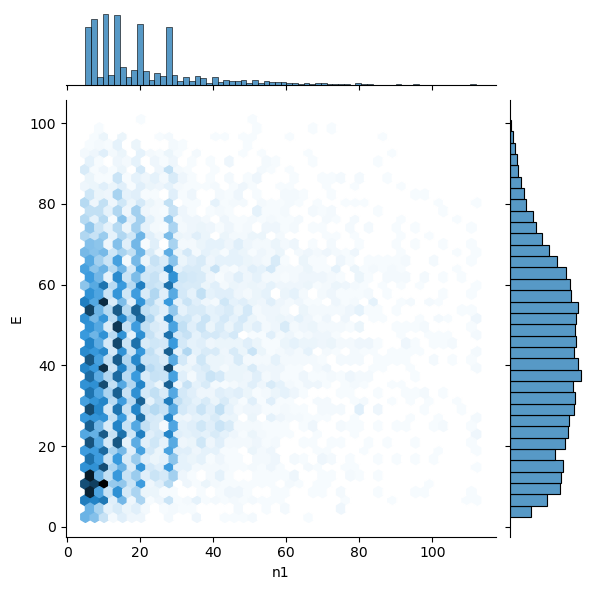

In [279]:
sns.jointplot(data=pred, x='n1', y='E', kind='hex', bins=100)


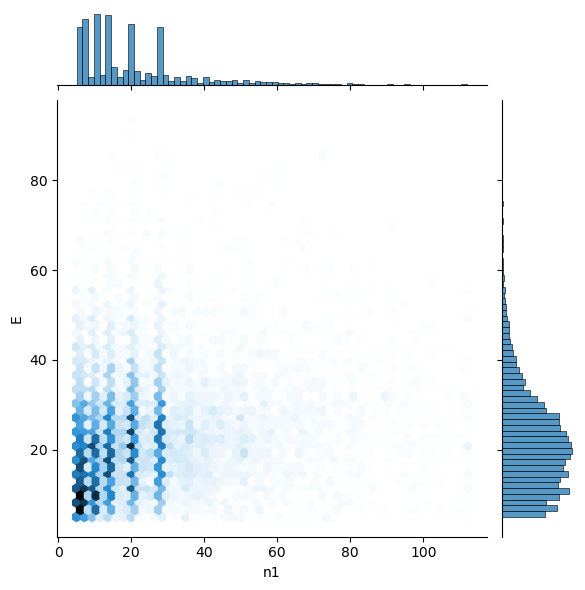

In [278]:
sns.jointplot(data=pred_post, x='n1', y='E', kind='hex', bins=100)


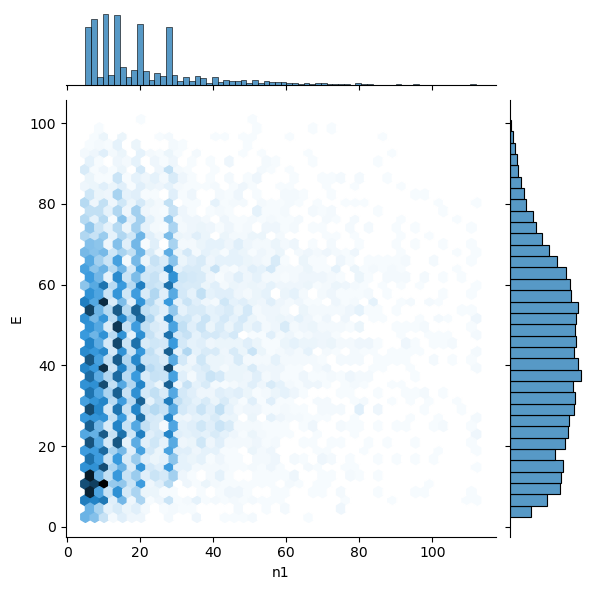

In [270]:
sns.jointplot(data=pred, x='n1', y='E', kind='hex', bins=100)

<Axes: xlabel='n1', ylabel='abs(error)'>

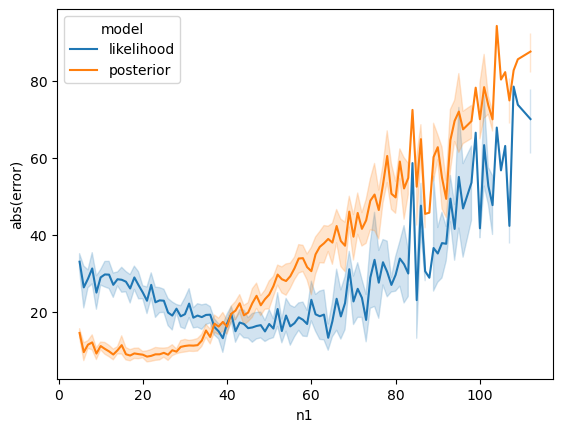

In [243]:
pred_all = pd.concat((pred, pred_post), keys=['likelihood', 'posterior'], names=['model'])

sns.lineplot(x='n1', y='abs(error)', data=pred_all.groupby(['subject', 'session', 'n1', 'model'])[['abs(error)']].mean().reset_index(), hue='model')

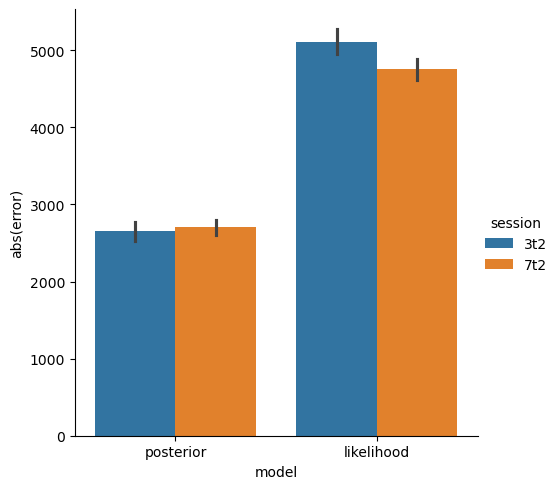

In [244]:
error_post = pred_post.groupby(['subject', 'session'])['abs(error)'].sum()
error_ll = pred.groupby(['subject', 'session'])['abs(error)'].sum()

error = pd.concat((error_post, error_ll), keys=['posterior', 'likelihood'], names=['model']).reset_index()

sns.catplot(x='model', y='abs(error)', data=error, kind='bar', hue='session', errorbar='se')

<Axes: xlabel='n1', ylabel='abs(error)'>

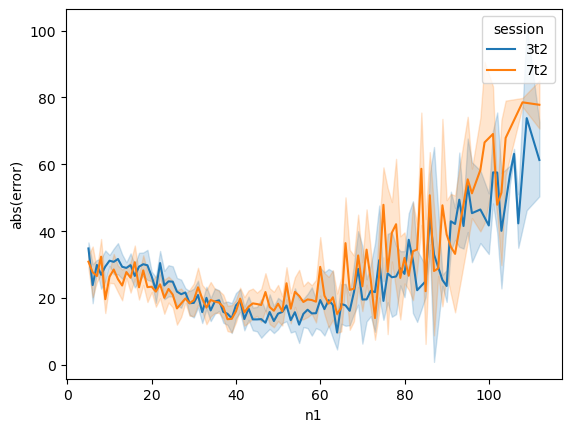

In [241]:
sns.lineplot(x='n1', y='abs(error)', data=pred, hue='session')

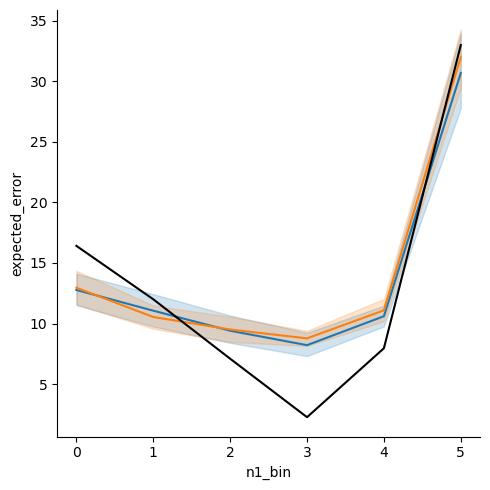

In [242]:
pred_post['abs(error)'] = (pred_post['E_posterior'] - pred_post['n1']).abs()
pred_post['expected_error'] = pred_post.groupby(['subject', 'session'])['n1'].transform(lambda d: (d-d.mean()).abs())


g = sns.FacetGrid(pred_post.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean().reset_index(), height=5.)

g.map_dataframe(sns.lineplot, 'n1_bin', 'abs(error)', hue='session')
g.map_dataframe(sns.lineplot, x='n1_bin', y='expected_error', color='black', errorbar=None)
# sns.lineplot(x='n1', y='abs(error)', data=pred_post, hue='session')

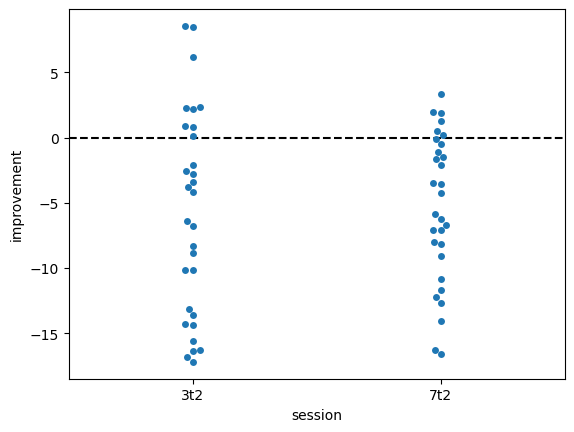

In [211]:
tmp = pred_post.groupby(['subject', 'session', 'n1_bin'])[['abs(error)', 'expected_error']].mean()

improvement = (tmp['expected_error'] - tmp['abs(error)'])

sns.swarmplot(x='session', y='improvement', data=improvement.groupby(['subject' ,'session']).sum().to_frame('improvement').reset_index())
plt.axhline(0.0, c='k', ls='--')

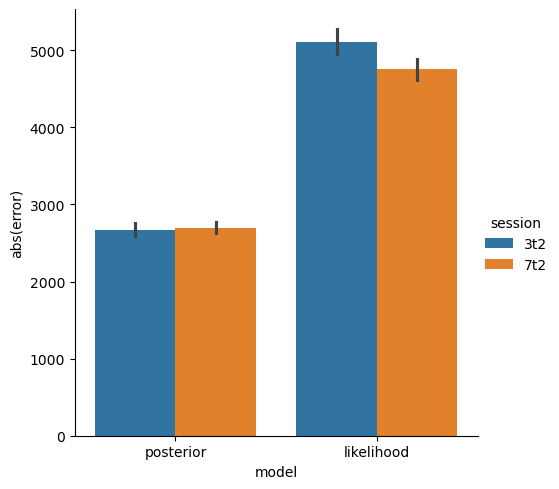

In [205]:
error_post = pred_post.groupby(['subject', 'session'])['abs(error)'].sum()
error_ll = pred.groupby(['subject', 'session'])['abs(error)'].sum()

error = pd.concat((error_post, error_ll), keys=['posterior', 'likelihood'], names=['model']).reset_index()

sns.catplot(x='model', y='abs(error)', data=error, kind='bar', hue='session', errorbar='se')

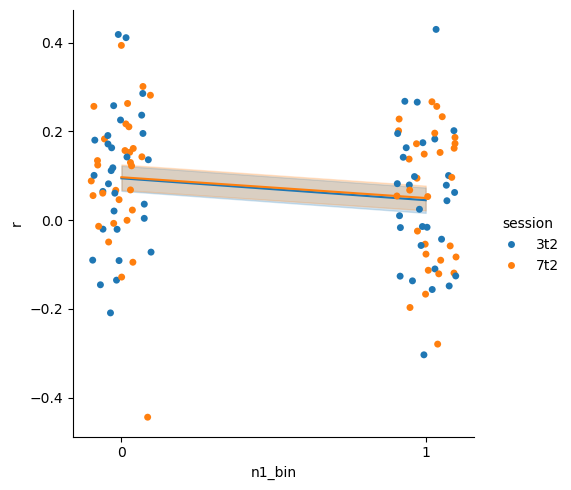

In [95]:
pred['n1_bin'] = pred.groupby(['subject', 'session'])['n1'].transform(lambda d: pd.qcut(d, 2, labels=False))

r = pred.groupby(['subject', 'session', 'n1_bin']).apply(lambda d: pingouin.corr(d['n1'], d['E']))


g = sns.catplot(x='n1_bin', y='r', data=r.reset_index(), hue='session', errorbar='se')

g.map_dataframe(sns.lineplot, 'n1_bin', 'r', hue='session', errorbar='se')

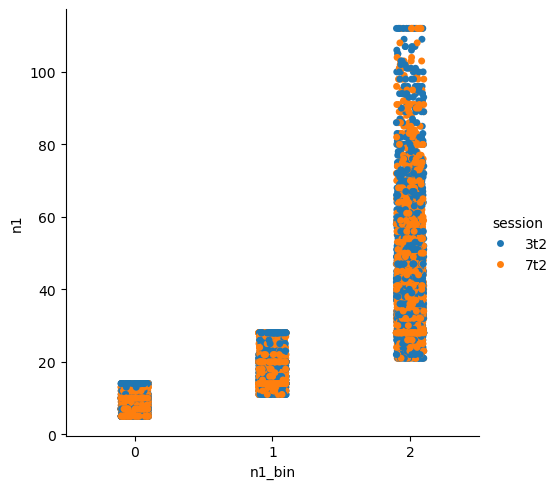

In [88]:
sns.catplot(x='n1_bin', y='n1', data=pred.reset_index(), hue='session', errorbar='se')

In [55]:
sns.lineplot(x='n1_bin', y='abs(error)', data=pred, hue='session')

ValueError: Could not interpret value `n1_bin` for `x`. An entry with this name does not appear in `data`.

In [44]:
import numpy as np


TypeError: cannot convert the series to <class 'float'>

In [18]:
import pandas as pd
pred_sorted['rolling_abs_diff'] = pred_sorted.groupby(['subject', 'session']).apply(lambda d: d.rolling(10).apply(lambda d: (d['E'] - d['n1']).abs()))


KeyError: 'E'

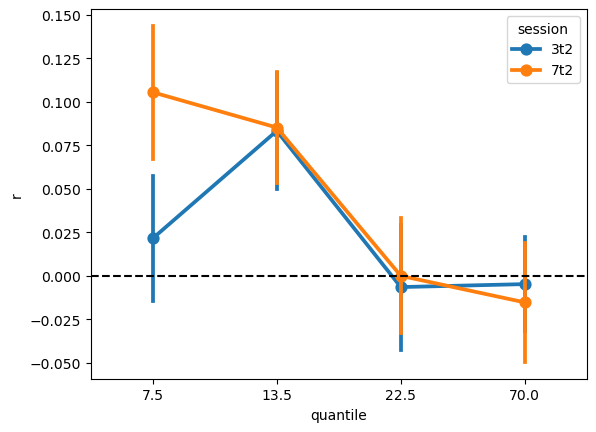

In [366]:
n_bins = 4
quantiles = df['n1'].quantile(np.linspace(0, 1, n_bins+1))

results = []

for q1, q2 in zip(quantiles.iloc[:-1], quantiles.iloc[1:]):
    
    d = df.query(f'n1 >= {q1} and n1 < {q2}').join(pdfs)

    pdf = pdfs.droplevel(['mask', 'n_voxels', 'old']).loc[d.index]

    pdf = pdf.loc[:, q1:q2]

    E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)

    results.append(E)

results = pd.concat(results, keys=quantiles.rolling(2).mean().iloc[1:], names=['quantile']).to_frame('E')

results = results.join(df['n1'])


r = results.groupby(['subject', 'session', 'quantile']).apply(lambda d: pingouin.corr(d['n1'], d['E']))

sns.pointplot(x='quantile', y='r', hue='session', data=r.reset_index(), errorbar='se'), 'run'

plt.axhline(0.0, c='k', ls='--')

<Axes: xlabel='n1_bin', ylabel='E'>

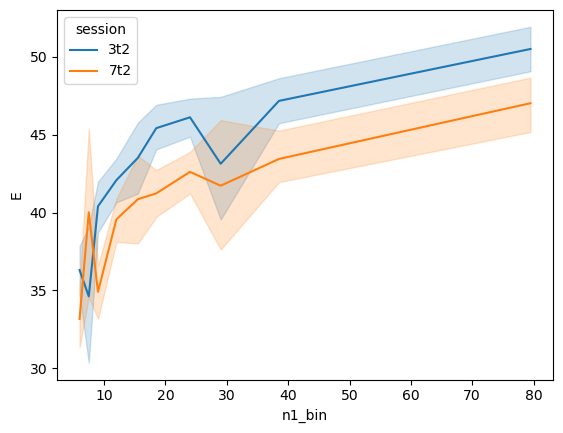

In [367]:
# pred['n1_bin'] = pred.groupby(['subject', 'session'])['n1'].transform(lambda d: pd.qcut(d, 2, labels=False))
n_bins = 10
quantiles = df['n1'].quantile(np.linspace(0, 1, n_bins+1))
pred['n1_bin'] = pd.cut(pred['n1'], quantiles)

pred['n1_bin'] = pred['n1_bin'].apply(lambda x: x.mid)
sns.lineplot(x='n1_bin', y='E', data=pred, hue='session')